## Things to do

* Add attension
* GUI, real-time visualization?
* Normalize only segmented data or just selected?

## Import Libaries

In [1]:
# Classification
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import Subset
import sherpa

# Manage datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Manage utils
import os 
from pathlib import Path
import sys
from datetime import datetime
import mne

current_dir = Path().resolve().parent.parent
sys.path.append(str(current_dir))

# Own implementations
from src.utilities.preprocessing import EEG_preprocessing, EMG_preprocessing #E402
from src.utilities.trainer_and_evaluator import FusionNet_train_eval, SingleNet_train_eval
from src.utilities.load_and_visualize_data import load_datasets, visualize_EEG

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

pin_memory = torch.cuda.is_available()              # Use pin_memory if CUDA is available
print("Pin memory set to:", pin_memory)

Using device: cpu
Pin memory set to: False


## Global variables

In [3]:
EMG_FREQ = 2000
EEG_FREQ = 125

EMG_LOWCUT = 20
EMG_HIGHCUT = 450
EEG_LOWCUT = 0.3
EEG_HIGHCUT = 32

EEG_NUM_CH = 3
EEG_NUM_CH = 16

NUM_EPOCHS = 30
TRIAL_PERIOD = 9
TRIM_PERIOD = 3

RMS_SAMPLING_WINDOW = 200
RMS_WINDOW_STEPSIZE = 50

HAMPEL_WINDOWSIZE = 100
HAMPEL_SIGMA = 3.0

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

EEG_CH_NAMES = [
    "Fp1", "Fp2",   # frontal pole
    "C3",  "C4",    # central
    "T5",  "T6",    # temporal (posterior)
    "Cz",  "Fz",    # occipital
    "F7",  "F8",    # temporal (anterior)
    "F3",  "F4",    # frontal
    "T3",  "T4",    # temporal (mid)
    "P3",  "P4"     # parietal
]

EMG_CH_NAMES = [
'Channel 1 : Palmaris longus',
'Channel 2 : Flexor digitorum superficialis',
'Channel 3 : Flexor pollicis longus',
]

## Step 1: Define the LSTM Model

In [4]:
class Attension(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.attn = nn.Linear(in_features = hidden_dim, out_features = 1)
    
    def forward(self, lstm_out):
        """
        Parameter
        ---------
        lstm_out : Tensor
            Output from LSTM with shape (batch, seq_len, hidden)
        
        Return
        --------
        context : Tensor
            Weighted sum over time (batch, hidden)
        
        weights : Tensor
            attension weights (batch, seq_len, 1)
        """
        # Compute attension scores
        scores = self.attn(lstm_out)                 # (Batch, seq_len, 1)
        weights = torch.softmax(scores, dim = 1)     # Apply softmax over 'seq_len' - (Batch, seq_len, 1)

        # Weigted sum over time - NOTE: The context vector summarizes the most relevant information from the input sequence and is fed to the decoder.
        context = torch.sum(input = weights * lstm_out, dim = 1)    # (Batch, hidden)

        return context, weights
    
class SingleNet(nn.Module):
    def __init__(self, data_ch, hidden = 32, lstm_layers = 1, num_classes = 2, dropout = 0.3, activation = 'relu'):
        super().__init__()
        '''
        Args:
            input_dim - int
                The number of expected features in the input sequence at each time step (n_channels)
            hidden_dim - int
                The number of features in the hidden state. How much memory should present the hidden state at one time stamp
            layer_dim - int
                Stacking multiple LSTM layers deepens the model. If is not in the timestamp direction. But the hiddenstate goes into the input of another LSTM.
            output_dim - int
                Maps the hidden state in nn.Linear outputs to predictions (n_classes)
        '''
        first_layer = hidden // 2    # (64) // 2 = 32

        self.lstm = nn.LSTM(input_size = data_ch, 
                            hidden_size = hidden, 
                            num_layers = lstm_layers, 
                            batch_first = True)       # Input dim (batch size, sequence length, input_size)
        
        self.attension = Attension(hidden_dim = hidden)

        activations = {
            'relu' : nn.ReLU(),
            'elu' : nn.ELU()
        }
        act = activations[activation]
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden, first_layer),            # 64
            act,
            nn.Dropout(dropout),
            nn.Linear(first_layer, num_classes)
        )

    def forward(self, data):
        '''
        Runs the data through LSTM + Fully Connected layer
        Args:
            X - DataLoader tensor with dimension: (batch, seq_len, channels)
        Returns:
            out: 
                The last time step of the LSTM
        '''
        lstm_out, _ = self.lstm(data)          # lstm_out (batch, seq_len, hidden), h (1, batch, hidden)

        context, attn_weights = self.attension(lstm_out)

        logits = self.classifier(context)

        return logits, context, attn_weights
        '''forward without attension
        _, (h, _) = self.lstm(data)           

        h_final = h[-1]

        return self.classifier(h_final), h_final
        '''

class FusionNet(nn.Module):
    def __init__(self, eeg_ch, emg_ch, hidden=32, lstm_layers = 1, num_classes=2, dropout = 0.3, activation = 'relu'):
        super().__init__()

        num_biosignals = 2
        first_layer = (hidden * num_biosignals) // 2    # (64) // 2 = 32

        self.eeg_lstm = nn.LSTM(input_size = eeg_ch, hidden_size = hidden, num_layers = lstm_layers, batch_first=True)
        self.emg_lstm = nn.LSTM(input_size = emg_ch, hidden_size = hidden, num_layers = lstm_layers, batch_first=True)

        self.attension = Attension(hidden_dim = hidden * num_biosignals)

        # WHAT OTHER ACTIVATIONS IS OF INTERST?
        activations = {
            'relu' : nn.ReLU(),
            'elu' : nn.ELU()
        }
        act = activations[activation]

        self.classifier = nn.Sequential(
            nn.Linear(hidden * num_biosignals, first_layer),            # 64
            act,
            nn.Dropout(dropout),
            nn.Linear(first_layer, num_classes)
        )

    def forward(self, eeg, emg):
        lstm_out_eeg, _ = self.eeg_lstm(eeg)          # lstm_out (batch, seq_len, hidden), h (1, batch, hidden)
        lstm_out_emg, _ = self.emg_lstm(emg)
        
        fused_seq = torch.cat([lstm_out_eeg, lstm_out_emg], dim=2)  # (batch, seq, hidden*2)
        
        context, attn_weights = self.attension(fused_seq)
        
        logits = self.classifier(context)

        return logits, context, attn_weights                        # Return dim : (batch, hidden_states for num_clases)

class SingleManageDataset(torch.utils.data.Dataset):
    def __init__(self, data, labels):
        '''
        Takes in the concatinated dataset of all trials, samples and channels.
        Args:
            X [ndArray] - with the dimension of (trials, samples, channels)
            y [int] - Indicate the number of trials 
        '''
        # Convert to tensors
        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.rng = np.random.default_rng(SEED)

        print('data shape:', self.data.shape)
        print('labels shape:', self.labels.shape)
    
    def create_test_train_dataset(self, train_procent = 0.8):
        '''
        Return:
            train_dataset - 
            test_dataset -
        '''
        N_labels = len(self.labels)
        indices = self.rng.permutation(N_labels)            # Shuffle labels
        
        train_size = int(train_procent * N_labels)
        train_idx = indices[:train_size]
        test_idx  = indices[train_size:]

        return train_idx, test_idx
    
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

    def get_rng_generator(self):
        return self.rng

class MultiManageDataset(torch.utils.data.Dataset):
    def __init__(self, eeg, emg, labels):
        self.eeg = torch.tensor(eeg, dtype=torch.float32)
        self.emg = torch.tensor(emg, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.rng = np.random.default_rng(SEED)

        print('eeg shape:', self.eeg.shape)
        print('emg shape:', self.emg.shape)
        print('labels shape:', self.labels.shape)
    
    def create_test_train_dataset(self, train_procent = 0.8):
        N_labels = len(self.labels)
        indices = self.rng.permutation(N_labels)            # Shuffle labels
        
        train_size = int(train_procent * N_labels)
        train_idx = indices[:train_size]
        test_idx  = indices[train_size:]

        return train_idx, test_idx
    
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.eeg[idx], self.emg[idx], self.labels[idx]

## TEST ATTENSION

In [22]:
def generate_attention_toy_data(
    n_samples=200,
    seq_len=100,
    noise_std=0.2
):
    X = np.random.normal(0, noise_std, size=(n_samples, seq_len, 1))
    y = np.zeros(n_samples, dtype=int)

    for i in range(n_samples):
        if i < n_samples // 2:
            # Class 0 → early spike
            X[i, 18:23, 0] += 2.0
            y[i] = 0
        else:
            # Class 1 → late spike
            X[i, 68:73, 0] += 2.0
            y[i] = 1

    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype = torch.long)

In [ ]:
model = SingleNet(
    data_ch=1,
    hidden=32,
    num_classes=2
)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

X, y = generate_attention_toy_data()

for epoch in range(30):
    optimizer.zero_grad()
    logits, _, _, _ = model(X)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        acc = (logits.argmax(1) == y).float().mean().item()
        print(f"Epoch {epoch:02d} | Loss {loss:.3f} | Acc {acc:.3f}")


Epoch 00 | Loss 0.694 | Acc 0.500
Epoch 05 | Loss 0.694 | Acc 0.500
Epoch 10 | Loss 0.695 | Acc 0.480
Epoch 15 | Loss 0.696 | Acc 0.470
Epoch 20 | Loss 0.693 | Acc 0.530
Epoch 25 | Loss 0.693 | Acc 0.510


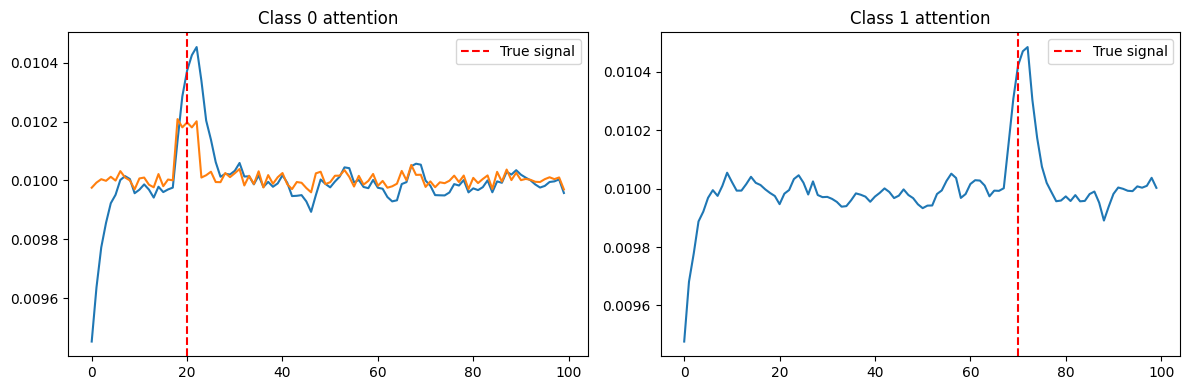

In [35]:
model.eval()

with torch.no_grad():
    logits, context, attn, _ = model(X)

# Pick one example from each class
idx0 = 10
idx1 = 150

attn0 = attn[idx0].squeeze().cpu().numpy()
attn1 = attn[idx1].squeeze().cpu().numpy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(attn0)
plt.plot(X[10, :, 0]/10000 + 0.01)
plt.axvline(20, color='r', linestyle='--', label='True signal')
plt.title("Class 0 attention")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(attn1)
plt.axvline(70, color='r', linestyle='--', label='True signal')
plt.title("Class 1 attention")
plt.legend()

plt.tight_layout()
plt.show()


## Step 2: Prepare Data

### EEG data sets

In [5]:
base_dir = Path().resolve().parent / 'experiment/data'

load_ins = load_datasets(base_dir = base_dir)

''' LOAD MARKERS FOR PLOTS
marker_index_files01 = load_ins.find_flex_files(
    subjects = ["subject_0", "subject_1"],
    modality = 'Markers',
    fingers = 'index',
    prefix = 'flex'
)

marker_thumb_files01 = load_ins.find_flex_files(
    subjects = ["subject_0", "subject_1"],
    modality = 'Markers',
    fingers = 'thumb',
    prefix = 'flex'
)

marker_index_files2 = load_ins.find_flex_files(
    subjects = ["subject_2"],
    modality = 'Markers',
    fingers = 'index',
    prefix = 'flex'
)

marker_thumb_files2 = load_ins.find_flex_files(
    subjects = ["subject_2"],
    modality = 'Markers',
    fingers = 'thumb',
    prefix = 'flex'
)

markers_index01 = load_ins.load_datasets_marker(
    path_to_data_files = marker_index_files01
)

markers_thumb01 = load_ins.load_datasets_marker(
    path_to_data_files = marker_thumb_files01
)

markers_index2 = load_ins.load_datasets_marker(
    path_to_data_files = marker_index_files2
)

markers_thumb2 = load_ins.load_datasets_marker(
    path_to_data_files = marker_thumb_files2
)'''

'''INDEX VS. THUMB
EEG_index_files01 = load_ins.find_flex_files(
    subjects=["subject_0", "subject_1"],
    modality="EEG",
    fingers=["index"],
    prefix = 'flex'
)

EEG_thumb_files01 = load_ins.find_flex_files(
    subjects=["subject_0", "subject_1"],
    modality="EEG",
    fingers=["thumb"],
    prefix = 'flex'
)

EEG_index_files2 = load_ins.find_flex_files(
    subjects=["subject_2"],
    modality="EEG",
    fingers=["index"],
    prefix = 'flex'
)

EEG_thumb_files2 = load_ins.find_flex_files(
    subjects=["subject_2"],
    modality="EEG",
    fingers=["thumb"],
    prefix = 'flex'
)


EEG_ins01 = EEG_preprocessing(fs = EEG_FREQ)
EEG_ins2 = EEG_preprocessing(fs = EEG_FREQ)

EEG_index01, EEG_index_epoch01, EEG_index_epoch_mean01, total_epochs = load_ins.load_datasets_EEG(
    path_to_data_files = EEG_index_files01,
    preprocessing_func = EEG_ins01.preprocessing_routine,
    bandpass_lowcut = EEG_LOWCUT,
    bandpass_highcut = EEG_HIGHCUT,
    extract_event = 'contract',
    trial_period = 4
    )

EEG_thumb01, EEG_thumb_epoch01, EEG_thumb_epoch_mean01, total_epochs = load_ins.load_datasets_EEG(
    path_to_data_files = EEG_thumb_files01,
    preprocessing_func = EEG_ins01.preprocessing_routine,
    bandpass_lowcut = EEG_LOWCUT,
    bandpass_highcut = EEG_HIGHCUT,
    extract_event = 'contract',
    trial_period = 4)

EEG_index2, EEG_index_epoch2, EEG_index_epoch_mean2, total_epochs = load_ins.load_datasets_EEG(
    path_to_data_files = EEG_index_files2,
    preprocessing_func = EEG_ins2.preprocessing_routine,
    bandpass_lowcut = EEG_LOWCUT,
    bandpass_highcut = EEG_HIGHCUT,
    extract_event = 'contract',
    trial_period = 3
    )

EEG_thumb2, EEG_thumb_epoch2, EEG_thumb_epoch_mean2, total_epochs = load_ins.load_datasets_EEG(
    path_to_data_files = EEG_thumb_files2,
    preprocessing_func = EEG_ins2.preprocessing_routine,
    bandpass_lowcut = EEG_LOWCUT,
    bandpass_highcut = EEG_HIGHCUT,
    extract_event = 'contract',
    trial_period = 3
    )'''

EEG_index_files = load_ins.find_flex_files(
    subjects=["subject_0_closedEyes", "subject_1_closedEyes", "subject_2", "subject_3", "subject_4", "subject_5"],
    modality="EEG",
    fingers=["index"],
    prefix = 'flex'
)

EEG_thumb_files = load_ins.find_flex_files(
    subjects=["subject_0_closedEyes", "subject_1_closedEyes", "subject_2", "subject_3", "subject_4", "subject_5"],
    modality="EEG",
    fingers=["thumb"],
    prefix = 'flex'
)

EEG_ins = EEG_preprocessing(fs = EEG_FREQ, bandpass_lowcut = EEG_LOWCUT, bandpass_highcut = EEG_HIGHCUT, trial_period = TRIAL_PERIOD, trim_period = TRIM_PERIOD)

EEG_index, EEG_index_epoch, EEG_index_epoch_mean, total_epochs = load_ins.load_datasets_EEG(
    path_to_data_files = EEG_index_files,
    preprocessing_func = EEG_ins.preprocessing_routine
    )

EEG_thumb, EEG_thumb_epoch, EEG_thumb_epoch_mean, total_epochs = load_ins.load_datasets_EEG(
    path_to_data_files = EEG_thumb_files,
    preprocessing_func = EEG_ins.preprocessing_routine
    )

------------------
Process for EEG data
------------------

C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_0_closedEyes\EEG\flex_index_finger_2026-02-05 14-19-21.csv


Original shape (34569, 16)
EEG_trim shape: (33750, 16)

C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_0_closedEyes\EEG\flex_index_finger_2026-02-05 14-24-42.csv
Original shape (34509, 16)
EEG_trim shape: (33750, 16)

C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_0_closedEyes\EEG\flex_index_finger_2026-02-05 14-37-01.csv
Original shape (34509, 16)
EEG_trim shape: (33750, 16)

C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_1_closedEyes\EEG\flex_index_finger_2026-02-06 10-32-15.csv
Original shape (34509, 16)
EEG_trim shape: (33750, 16)

C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_1_closedEyes\EEG\flex_index_finger_2026-02-06 10-39-19.csv
Original shape (34510, 16)
EEG_trim shape: (33750, 16)

C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_1_closedEyes\EEG\flex_index_finger_2026-02-06 10-48-03.csv
Original shape (34569, 16)
EEG_trim shape: (33750, 16)

C:\Users\Bruger\Documents\hybrid_bci\src\exp

### EMG data sets

In [28]:
base_dir = Path().resolve().parent / 'experiment/data'

load_ins = load_datasets(base_dir = base_dir)

EMG_index_files = load_ins.find_flex_files(
    subjects=["subject_0_closedEyes", "subject_1_closedEyes", "subject_2", "subject_3", "subject_4", "subject_5"],
    modality="EMG",
    fingers=["index"],
    prefix = 'flex'
)

EMG_thumb_files = load_ins.find_flex_files(
    subjects=["subject_0_closedEyes", "subject_1_closedEyes", "subject_2", "subject_3", "subject_4", "subject_5"],
    modality="EMG",
    fingers=["thumb"],
    prefix = 'flex'
)

print(len(EMG_index_files))

EMG_ins = EMG_preprocessing(fs = EMG_FREQ,
                            bandpass_lowcut = EMG_LOWCUT,
                            bandpass_highcut = EMG_HIGHCUT,
                            trial_period = TRIAL_PERIOD,
                            trim_period = TRIM_PERIOD)

RMS_list_index, EMG_list_index, total_epochs = load_ins.load_datasets_EMG(
    path_to_data_files = EMG_index_files,
    preprocessing_func = EMG_ins.preprocessing_routine,
    rms_windowsize = 32,
    rms_stepsize = 16,
    hampel_windowsize = HAMPEL_WINDOWSIZE,
    hampel_sigma = HAMPEL_SIGMA,
    hampel_plot_option = [False, None],
    include_EMG = True)

RMS_list_thumb, EMG_list_thumb, total_epochs = load_ins.load_datasets_EMG(
    path_to_data_files = EMG_thumb_files,
    preprocessing_func = EMG_ins.preprocessing_routine,
    rms_windowsize = 32,
    rms_stepsize = 16,
    hampel_windowsize = HAMPEL_WINDOWSIZE,
    hampel_sigma = HAMPEL_SIGMA,
    hampel_plot_option = [False, None],
    include_EMG = True)

20
------------------
Process for EMG data
------------------

C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_0_closedEyes\EMG\flex_index_finger_2026-02-05 14-19-21.csv
Original shape (551800, 3)
EEG_trim shape: (540000, 3)

Did resample from 33749 to 33750
Total Time 270 s
RMS fs: 124.9962962962963 Hz
RMS shape: (33750, 3)
EMG shape: (540000, 3)

C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_0_closedEyes\EMG\flex_index_finger_2026-02-05 14-24-42.csv
Original shape (552000, 3)
EEG_trim shape: (540000, 3)

Did resample from 33749 to 33750
Total Time 270 s
RMS fs: 124.9962962962963 Hz
RMS shape: (33750, 3)
EMG shape: (540000, 3)

C:\Users\Bruger\Documents\hybrid_bci\src\experiment\data\subject_0_closedEyes\EMG\flex_index_finger_2026-02-05 14-37-01.csv
Original shape (552200, 3)
EEG_trim shape: (540000, 3)

Did resample from 33749 to 33750
Total Time 270 s
RMS fs: 124.9962962962963 Hz
RMS shape: (33750, 3)
EMG shape: (540000, 3)

C:\Users\Bruger\Docume

### BCI2a Dataset

In [19]:
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler
def bandpass_filter(data, fs, low, high, order=4):
    """
    Zero-phase Butterworth bandpass filter
    data: (samples, channels)
    """
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, data, axis=0)


def standardize_epochs(X):
    """
    Channel-wise z-score normalization
    X shape: (trials, samples, channels)
    """
    Xn = np.zeros_like(X)
    for ch in range(X.shape[2]):
        scaler = StandardScaler()
        Xn[:, :, ch] = scaler.fit_transform(X[:, :, ch])
    return Xn

#=============#
# CORE LOADER #
#=============#
def load_subject(subject_id, sel_mode, sel_class_type):
    '''
    Parameters
    ----------
    sel_class_type : str
        '769' for left hand MI
        '770' for right hand MI
    '''
    event_dict = {
        '769' : 'left_hand',
        '770' : 'right_hand',
        '783' : 'Cue_unknown'
    }

    FS = 250  # Sampling frequency
    TMIN = 0.0              # start at cue
    TMAX = 6.0              # 4 seconds MI
    ONSET_TMIN = 0.0        # onset window
    ONSET_TMAX = 3.0        # End of onset
    BANDPASS = (8, 32)  # mu + beta band

    mode = "T" if sel_mode else "E"
    fname = f"A{subject_id:02d}{mode}.gdf"

    filepath = Path().resolve().parent / 'utilities/BCI2a_dataset' / fname

    # Load GDF file
    raw = mne.io.read_raw_gdf(str(filepath), preload=True, verbose=False)

    # Drop EOG channels
    eeg_chs = raw.info["ch_names"][:22]
    raw.pick(eeg_chs)

    # Extract events
    events, event_id = mne.events_from_annotations(raw)
    
    print(event_id)
    class_type = event_id[sel_class_type]

    # keep only MI events
    events_mi = events[events[:, 2] == class_type]

    # Epoching
    epochs = mne.Epochs(
        raw,
        events_mi,
        event_id={event_dict[sel_class_type]: class_type},
        tmin=TMIN,
        tmax=TMAX,
        baseline=None,
        preload=True,
        verbose=False
    )

    # crop to only onset
    epochs_onset = epochs.copy().crop(tmin=ONSET_TMIN, tmax = ONSET_TMAX)

    X = epochs_onset.get_data()           # (trials, channels, samples)
    X = np.transpose(X, (0, 2, 1))  # Reorder to (trials, samples, channels)

    continous_datastream = epochs.get_data()                                # (trials, channels, samples)
    continous_datastream = np.transpose(continous_datastream, (0, 2, 1))    # Reorder to (trials, samples, channels)

    # Labels (single source of truth)
    y = np.array([events_mi[e] for e in epochs.events[:, 2]])


    for i in range(X.shape[0]):     # Move this above epochs
        X[i] = bandpass_filter(X[i], FS, BANDPASS[0], BANDPASS[1])

    # Normalize
    X = standardize_epochs(X)

    print("\n")
    print(X.shape)           # (n_trials, time, 22)
    print(np.unique(y))      # [0 1 2 3]
    assert len(X) == len(y)

    return X, y, continous_datastream

# ---------------------------
# LOAD ALL SUBJECTS
# ---------------------------

def load_all_subjects(sel_mode=True, sel_class_type = '0', num_subj = 2):
    """
    Loads all 9 subjects
    """
    if num_subj < 2 or num_subj > 10:
        raise ValueError(f'num_subj {num_subj} must be between 2 and 10')
    X_all, y_all = [], []

    for subj in range(1, num_subj):
        X, y, cds = load_subject(subject_id = subj, sel_mode = sel_mode, sel_class_type = sel_class_type)

        X_all.append(X)
        y_all.append(y)

        print(f"Subject {subj}: {X.shape}, labels: {np.unique(y)}")

    return np.concatenate(X_all), np.concatenate(y_all)

In [20]:
X_train_left, y_train_left = load_all_subjects(sel_mode=True, sel_class_type='769', num_subj=10)
# X_eva_left, y_eva_left = load_all_subjects(sel_mode=False, sel_class_type='783', num_subj=10)

X_train_right, y_train_right = load_all_subjects(sel_mode=True, sel_class_type='770', num_subj=10)
# X_eva_right, y_eva_right = load_all_subjects(sel_mode=False, sel_class_type='783', num_subj=10)

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}


(71, 751, 22)
[     0      7 130236]
Subject 1: (71, 751, 22), labels: [     0      7 130236]
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}


(72, 751, 22)
[     0      7 142970]
Subject 2: (72, 751, 22), labels: [     0      7 142970]
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
{'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}


(72, 751, 22)
[     0      7 126331]
Subject 3: (72, 751, 22), labels: [     0      7 126331]
Used Annotations descriptions: ['1023', '1072', '32766', '768', '769', '770'

### Divide data into rest, con, rel

In [7]:
#======================#
# EMG ONLY - 5 classes #
#======================#
'''
RMS_FREQ = 125
RMS_index_epoch = RMS_list_index[1]
RMS_thumb_epoch = RMS_list_thumb[1]

RMS_index_epoch_res = RMS_index_epoch[:, :3*RMS_FREQ, :].copy()
RMS_index_epoch_con = RMS_index_epoch[:, 3*RMS_FREQ : 6*RMS_FREQ, :].copy()
RMS_index_epoch_rel = RMS_index_epoch[:, 6*RMS_FREQ:, :].copy()

RMS_thumb_epoch_res = RMS_thumb_epoch[:, :3*RMS_FREQ, :].copy()
RMS_thumb_epoch_con = RMS_thumb_epoch[:, 3*RMS_FREQ : 6*RMS_FREQ, :].copy()
RMS_thumb_epoch_rel = RMS_thumb_epoch[:, 6*RMS_FREQ:, :].copy()

# DO FROM HERE
print(f'EMG index rest shape: {RMS_index_epoch_res.shape}\n'
      f'EMG index con shape: {RMS_index_epoch_con.shape}\n'
      f'EMG index rel shape: {RMS_index_epoch_rel.shape}\n'
      f'EMG thumb rest shape: {RMS_thumb_epoch_res.shape}\n'
      f'EMG thumb con shape: {RMS_thumb_epoch_con.shape}\n'
      f'EMG thumb rel shape: {RMS_thumb_epoch_rel.shape}\n')
'''
#======================#
# EEG ONLY - 5 classes #
#======================#
sel_ch = [2, 3, 6, 7, 10, 11]

EEG_index_epoch_res = EEG_index_epoch[:, :3*EEG_FREQ, sel_ch].copy()
EEG_index_epoch_con = EEG_index_epoch[:, 3*EEG_FREQ : 6*EEG_FREQ, sel_ch].copy()
EEG_index_epoch_rel = EEG_index_epoch[:, 6*EEG_FREQ:, sel_ch].copy()

EEG_thumb_epoch_res = EEG_thumb_epoch[:, :3*EEG_FREQ, sel_ch].copy()
EEG_thumb_epoch_con = EEG_thumb_epoch[:, 3*EEG_FREQ : 6*EEG_FREQ, sel_ch].copy()
EEG_thumb_epoch_rel = EEG_thumb_epoch[:, 6*EEG_FREQ:, sel_ch].copy()

print(f'EEG index rest shape: {EEG_index_epoch_res.shape}\n'
      f'EEG index con shape: {EEG_index_epoch_con.shape}\n'
      f'EEG index rel shape: {EEG_index_epoch_rel.shape}\n'
      f'EEG thumb rest shape: {EEG_thumb_epoch_res.shape}\n'
      f'EEG thumb con shape: {EEG_thumb_epoch_con.shape}\n'
      f'EEG thumb rel shape: {EEG_thumb_epoch_rel.shape}\n')

EEG index rest shape: (540, 375, 6)
EEG index con shape: (540, 375, 6)
EEG index rel shape: (540, 375, 6)
EEG thumb rest shape: (539, 375, 6)
EEG thumb con shape: (539, 375, 6)
EEG thumb rel shape: (539, 375, 6)



### Contract Datasets and labels

In [10]:
#=======================#
# Multi fusion datasets #
#=======================#
'''EEG_X, EMG_X, labels = None, None, None

EEG_rest_data = np.concatenate( (EEG_index_epoch_res,
                                 EEG_thumb_epoch_res)
                                 )

RMS_rest_data = np.concatenate( (RMS_index_epoch_res,
                                 RMS_thumb_epoch_res)
                                 )

EEG_X = np.concatenate( (EEG_index_epoch_con,
                         EEG_index_epoch_rel,
                         EEG_thumb_epoch_con,
                         EEG_thumb_epoch_rel,
                         EEG_rest_data)
                         )

EMG_X = np.concatenate( (RMS_index_epoch_con,
                         RMS_index_epoch_rel,
                         RMS_thumb_epoch_con,
                         RMS_thumb_epoch_rel,
                         RMS_rest_data)
                         )

labels = np.concatenate( (np.zeros(EEG_index_epoch_con.shape[0]), 
                          np.ones(EEG_index_epoch_rel.shape[0]),
                          np.ones(EEG_thumb_epoch_con.shape[0]) + 1,
                          np.ones(EEG_thumb_epoch_rel.shape[0]) + 2,
                          np.ones(EEG_rest_data.shape[0]) + 3)
                          )

print('EEG X shape : ', EEG_X.shape)
print('EMG X shape : ', EMG_X.shape)
print('labels shape :', labels.shape)
'''
#=================#
# Single datasets #
#=================#
# EEG ONLY - 3 classes
X, labels = None, None

X = np.concatenate( (EEG_index_epoch_con,
                         EEG_index_epoch_rel,
                         EEG_index_epoch_res)
                         )

labels = np.concatenate( (np.zeros(EEG_index_epoch_con.shape[0]), 
                          np.ones(EEG_index_epoch_rel.shape[0]),
                          np.ones(EEG_index_epoch_res.shape[0]) + 1)
                          )

print('X shape : ', X.shape)
print('labels shape :', labels.shape)

'''# EMG ONLY - 5 classes
rest_data = np.concatenate((RMS_index_epoch_res, RMS_thumb_epoch_res))

X, labels = None, None
X = np.concatenate((RMS_index_epoch_con,
                    RMS_index_epoch_rel,
                    RMS_thumb_epoch_con,
                    RMS_thumb_epoch_rel,
                    rest_data)
                    )

labels = np.concatenate( (np.zeros(RMS_index_epoch_con.shape[0]),
                          np.ones(RMS_index_epoch_rel.shape[0]),
                          np.ones(RMS_thumb_epoch_con.shape[0]) + 1,
                          np.ones(RMS_thumb_epoch_rel.shape[0]) + 2,
                          np.ones(rest_data.shape[0]) + 3)
                          )

print('X shape : ', X.shape)
print('labels shape :', labels.shape)'''

'''# BCI 2a
X, labels = None, None
X = np.concatenate((X_train_left,
                   X_train_right)
                   )

labels = np.concatenate( (np.zeros(X_train_left.shape[0]), 
                          np.ones(X_train_right.shape[0]))
                          )
print('X shape : ', X.shape)
print('labels shape :', labels.shape)'''

X shape :  (1620, 375, 6)
labels shape : (1620,)


"# BCI 2a\nX, labels = None, None\nX = np.concatenate((X_train_left,\n                   X_train_right)\n                   )\n\nlabels = np.concatenate( (np.zeros(X_train_left.shape[0]), \n                          np.ones(X_train_right.shape[0]))\n                          )\nprint('X shape : ', X.shape)\nprint('labels shape :', labels.shape)"

In [23]:
def plot_emg_mean_epoch_single_channels(emg_epoch_mean, rms_epoch_mean, ch1 = 0, ch2 = 1, key1 = None, key2 = None):

    fig, axs = plt.subplots(
    1, 2,
    figsize=(18, 6),      # Before 162, 60
    dpi=400,                     # IMPORTANT
    gridspec_kw={"wspace": 0.05}, # spacing between figures
    sharey=True
    )
    #print('Channel Name :', EMG_CH_NAMES[emg_ch], 'and', EMG_CH_NAMES[rms_ch])

    emg1 = np.array(emg_epoch_mean[key1][:, ch1])
    rms1 = np.array(rms_epoch_mean[key1][:, ch1])

    emg2 = np.array(emg_epoch_mean[key2][:, ch2])
    rms2 = np.array(rms_epoch_mean[key2][:, ch2])

    time = np.arange(emg1.shape[0]) / EMG_FREQ
    RMS_window_size = int(0.1 * EMG_FREQ)  # 100 ms
    win_time = (np.arange(rms1.shape[0]) * (16) + 16) / EMG_FREQ


    axs[0].plot(time, emg1, color='royalblue', linewidth=1.0, label = 'Index finger')
    axs[0].plot(win_time, rms1, color = 'orange', linewidth = 1.0, label = 'RMS envelope')
    #axs[0].set_xlim([0, 9])
    #axs[0].set_ylim([-2, 2])
    #axs[0].set_xticks(np.arange(0.0, 9.01, 1.0))
    axs[0].set_xlabel('Time (s)')
    axs[0].set_ylabel('Standardized EMG (a.u)')
    axs[0].axvline(2, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].axvline(7, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].grid(True, alpha=0.3)
    axs[0].legend(loc = 'lower left')

    axs[0].text(2, plt.ylim()[1]*0.99, 'Contract', rotation=90, color='salmon', ha='left', va='top', fontsize=8)
    axs[0].text(7, plt.ylim()[1]*0.99, 'Release', rotation=90, color='salmon', ha='left', va='top', fontsize=8)

    axs[1].plot(time, emg2, color='royalblue', linewidth=1.0, label='Thumb')
    axs[1].plot(win_time, rms2, color = 'orange', linewidth = 1.0, label = 'RMS envelope')
    #axs[1].set_xlim([0, 9])
    #axs[1].set_xticks(np.arange(0.0, 9.01, 1.0))
    axs[1].set_xlabel('Time (s)')
    axs[1].axvline(2, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].axvline(7, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].grid(True, alpha=0.3)
    axs[1].legend(loc = 'lower left')

    axs[1].text(2, plt.ylim()[1]*0.99, 'Contract', rotation=90, color='salmon', ha='left', va='top', fontsize=8)
    axs[1].text(7, plt.ylim()[1]*0.99, 'Release', rotation=90, color='salmon', ha='left', va='top', fontsize=8)

def plot_EEG_across_channels(EEG_epoch, freq = 125, sel_ch = None):
    if EEG_epoch.ndim == 3:
        data = EEG_epoch.reshape(-1, 16).copy()
        print(data.shape)
    if EEG_epoch.ndim == 2:
        data = EEG_epoch.copy()

    n_samples, n_channels = data.shape
    time = np.arange(n_samples) / freq

    # --------------------------------------------------
    # 1) Find min/max for y-axis limits
    # --------------------------------------------------
    y_min = np.min(data)
    y_max = np.max(data)
    print(f'Y-axis limits: {y_min} to {y_max}')

    fig, axs = plt.subplots(8, 2, figsize=(30, 45))

    for ch in range(n_channels):
        row = ch // 2
        col = ch % 2
        axs[row, col].plot(time, data[:, ch])
        
        axs[row, col].set_title(f'Channel: {EEG_CH_NAMES[sel_ch[ch]]}')
        axs[row, col].set_xlabel('Time (s)')
        axs[row, col].set_ylabel('Amplitude (a.u)')
        
        axs[row, col].set_ylim(y_min, y_max)
        axs[row, col].grid()

def plot_EMG_across_channels(EMG_mean_epoch, freq = 2000):
    n_samples, n_channels = EMG_mean_epoch.shape
    time = np.arange(n_samples) / freq

    # --------------------------------------------------
    # 1) Find min/max for y-axis limits
    # --------------------------------------------------
    y_min = np.min(EMG_mean_epoch)
    y_max = np.max(EMG_mean_epoch)
    print(f'Y-axis limits: {y_min} to {y_max}')

    fig, axs = plt.subplots(n_channels, 1, figsize=(8, 13))

    for ch in range(n_channels):
        axs[ch].plot(time, EMG_mean_epoch[:, ch])
        
        axs[ch].set_title(f'Channel: {EMG_CH_NAMES[ch]}')
        axs[ch].set_xlabel('Time (s)')
        axs[ch].set_ylabel('Amplitude (a.u)')
        
        axs[ch].set_ylim(y_min, y_max)
        axs[ch].grid()

def plot_RMS_across_channels(RMS_epoch, freq = 2000, rms_window_stepsize = 50):
    if RMS_epoch.ndim == 3:
        data = RMS_epoch.reshape(-1, 3).copy()
        print(data.shape)
    if RMS_epoch.ndim == 2:
        data = RMS_epoch.copy()
        
        
    
    n_samples, n_channels = data.shape
    rws = rms_window_stepsize
    
    win_time = (np.arange(n_samples) * (rws) + rws) / freq

    # --------------------------------------------------
    # 1) Find min/max for y-axis limits
    # --------------------------------------------------
    y_min = np.min(data)
    y_max = np.max(data)
    print(f'Y-axis limits: {y_min} to {y_max}')

    fig, axs = plt.subplots(n_channels, 1, figsize=(16, 13))

    for ch in range(n_channels):
        axs[ch].plot(win_time, data[:, ch])
        
        axs[ch].set_title(f'Channel: {EMG_CH_NAMES[ch]}')
        axs[ch].set_xlabel('Time (s)')
        axs[ch].set_ylabel('Amplitude (a.u)')
        
        axs[ch].set_ylim(y_min, y_max)
        axs[ch].grid()

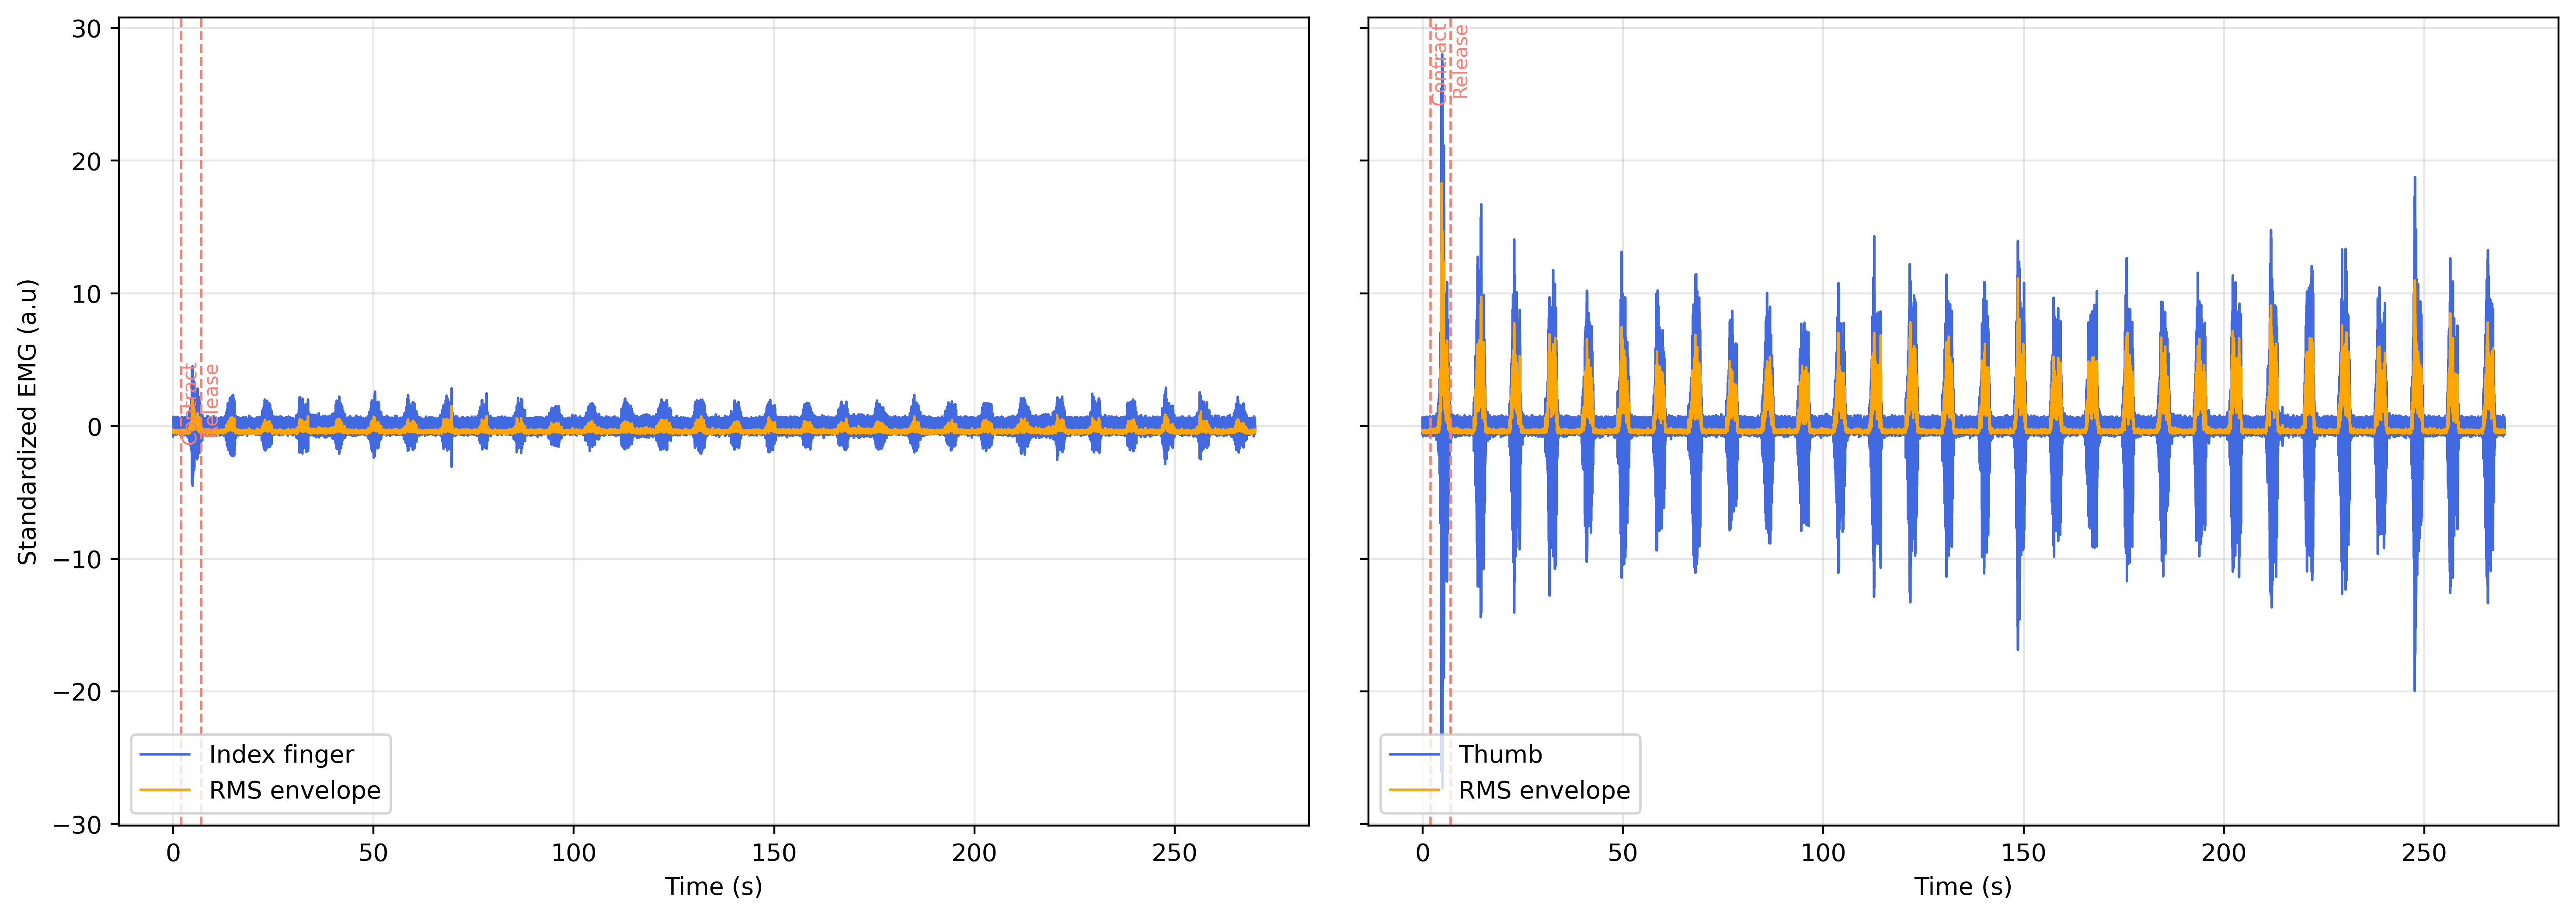

In [24]:
# plot_RMS_across_channels(RMS_index_epoch[0:90, :, :])
#plot_RMS_across_channels(EMG_index_epoch[60:90, :, :])

plot_emg_mean_epoch_single_channels(EMG_list_index, RMS_list_index, key1 = 0, key2 = 0)
# plot_EMG_across_channels(X_train_left.mean(axis=0), freq = 250)
#plot_EMG_across_channels(EMG_thumb_epoch_con.mean(axis=0))

# plot_EEG_across_channels(RMS_index_epoch_con.mean(axis=0), freq = 125, sel_ch = sel_ch)
# plot_EEG_across_channels(RMS_thumb_epoch_res.mean(axis=0), freq = 125, sel_ch = sel_ch)

## TEST LSTM WITH SINE AND SQURE SIGNALS

In [ ]:
from scipy.signal import chirp, sawtooth

N = 38000

rng1 = np.random.uniform(-2, 2, N)
rng2 = np.random.uniform(-2, 2, N)
rng3 = np.random.uniform(-2, 2, N)
rng4 = np.random.uniform(-1, 1, N//2)
rng5 = np.random.uniform(-1, 1, N//2)
rng6 = np.random.uniform(-1, 1, N//2)

# Class 1
EEG_sin_f1 = np.sin(np.arange(N) * 0.01 * np.pi + rng1)
EEG_sin_f2 = np.sin(np.arange(N) * 0.05 * np.pi + rng2)
EEG_sin_f3 = np.sin(np.arange(N) * 0.1 * np.pi + rng3)
EMG_cos_f1 = np.cos(np.arange(N//2) * 0.01 * np.pi + rng4)
EMG_cos_f2 = np.cos(np.arange(N//2) * 0.05 * np.pi + rng5)
EMG_cos_f3 = np.cos(np.arange(N//2) * 0.1 * np.pi + rng6)

# Class 2
EEG_tri_f1 = sawtooth(np.arange(N) * np.pi * 0.01 + rng1, 0.6)
EEG_tri_f2 = sawtooth(np.arange(N) * np.pi * 0.05 + rng2, 0.6)
EEG_tri_f3 = sawtooth(np.arange(N) * np.pi * 0.1 + rng3, 0.6)
EMG_tri_f1 = sawtooth(np.arange(N//2) * np.pi * 0.01 + rng4, 0.5)
EMG_tri_f2 = sawtooth(np.arange(N//2) * np.pi * 0.05 + rng5, 0.5)
EMG_tri_f3 = sawtooth(np.arange(N//2) * np.pi * 0.1 + rng6, 0.5)

# Stack features
EEG_class1 = np.column_stack((EEG_sin_f1, EEG_sin_f2, EEG_sin_f3))
EMG_class1 = np.column_stack((EMG_cos_f1, EMG_cos_f2, EMG_cos_f3))

EEG_class2 = np.column_stack((EEG_tri_f1, EEG_tri_f2, EEG_tri_f3))
EMG_class2 = np.column_stack((EMG_tri_f1, EMG_tri_f2, EMG_tri_f3))

# Make epochs
X_EEG_class1_epoch = EEG_class1.reshape(100, 380, 3)
X_EMG_class1_epoch = EMG_class1.reshape(100, 190, 3)

X_EEG_class2_epoch = EEG_class2.reshape(100, 380, 3)
X_EMG_class2_epoch = EMG_class2.reshape(100, 190, 3)

plt.figure()
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes[0, 0].plot(EEG_class1[:300, 0], label='EEG class 1 - Feature 1')
axes[0, 1].plot(EEG_class1[:300, 1], label='EEG class 1 - Feature 2')
axes[0, 2].plot(EEG_class1[:300, 2], label='EEG class 1 - Feature 3')

axes[1, 0].plot(EEG_class2[:300, 0], label='EEG class 2 - Feature 1')
axes[1, 1].plot(EEG_class2[:300, 1], label='EEG class 2 - Feature 2')
axes[1, 2].plot(EEG_class2[:300, 2], label='EEG class 2 - Feature 3')

for ax in axes.flat:
    ax.legend(loc = 'lower right')

plt.figure()
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes[0, 0].plot(EMG_class1[:300, 0], label='EMG class 1 - Feature 1')
axes[0, 1].plot(EMG_class1[:300, 1], label='EMG class 1 - Feature 2')
axes[0, 2].plot(EMG_class1[:300, 2], label='EMG class 1 - Feature 3')

axes[1, 0].plot(EMG_class2[:300, 0], label='EMG class 2 - Feature 1')
axes[1, 1].plot(EMG_class2[:300, 1], label='EMG class 2 - Feature 2')
axes[1, 2].plot(EMG_class2[:300, 2], label='EMG class 3 - Feature 3')

for ax in axes.flat:
    ax.legend(loc = 'lower right')

EEG_X, EMG_X, labels = None, None, None
EEG_X = np.concatenate((X_EEG_class1_epoch, X_EEG_class2_epoch))
EMG_X = np.concatenate((X_EMG_class1_epoch, X_EMG_class2_epoch))
labels = np.concatenate((np.zeros(X_EEG_class1_epoch.shape[0]), np.ones(X_EEG_class2_epoch.shape[0])))
# X = epoch_2t32['index']
# Y = np.zeros(epoch_2t32['index'].shape[0])

print(f'EEG shape: {EEG_X.shape}',
      f'\nEMG shape: {EMG_X.shape}',
      f'\nLabels shape: {labels.shape}')

## Define hyperparameters

In [13]:
parameters = [sherpa.Continuous(name='learning_rate', range=[0.0001, 0.001], scale='log'),
              sherpa.Continuous(name='dropout', range=[0., 0.4]),
              sherpa.Ordinal(name='batch_size', range=[16, 32, 64]),
              sherpa.Discrete(name='num_hidden_units', range=[32, 256]),         # before 64
              sherpa.Choice(name='activation', range=['relu', 'elu'])]

# Hyperparameter optimization algorithms
max_num_trials = 10
algorithm = sherpa.algorithms.RandomSearch(max_num_trials = max_num_trials)

# Study represents the hyperparameter optimization itself
study = sherpa.Study(
    parameters = parameters,
    algorithm = algorithm,
    lower_is_better = True,
    disable_dashboard = True
)
'''Additional hyperparameters
    Learning rate decay
    Number of dense nodes
    Number of filters
    Optimizer
'''

# records = []
# for trial in study:
#     acc = 7
#     row = {
#         "trial_id": trial.id,
#         **trial.parameters,
#         'accuracy' : acc
#         }
#     records.append(row)

'Additional hyperparameters\n    Learning rate decay\n    Number of dense nodes\n    Number of filters\n    Optimizer\n'

## Step 4: Train the LSTM Model

In [14]:
log_name = 'SingleNet_EEG_3classes_index_more_hidden_units'
log_dir = os.path.abspath(os.path.join(os.getcwd(), f'loggings\{log_name}'))    # Path to log results
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

#=======================#
# Multi fusion datasets #
#=======================#
# dataset_ins = MultiManageDataset(EEG_X, EMG_X, labels)
# train_eval_ins = FusionNet_train_eval()

#=================#
# Single datasets #
#=================#
dataset_ins = SingleManageDataset(data = X, labels = labels)
train_eval_ins = SingleNet_train_eval()

#========================================================#
# THESE PARAMETERS ARE CHANCEABLE, DEPENDING ON THE TASK #
#========================================================#
DATA_CH = 6
LSTM_LAYERS = 1
NUM_CLASSES = 3

train_idx, test_idx = dataset_ins.create_test_train_dataset(train_procent = 0.8)

num_epochs = 150
patience = 40                   # Early stopping patience - 25

L_all = {}
C_all = {}
W_all = {}
Y_all = {}

for trial in study:
    lr = trial.parameters['learning_rate']
    dropout = trial.parameters['dropout']       
    batch_size = trial.parameters['batch_size']
    num_hidden_units = trial.parameters['num_hidden_units']
    activation = trial.parameters['activation'] 

    #=======================#
    # Multi fusion datasets #
    #=======================#
    # model = FusionNet(eeg_ch = 6, emg_ch = 3, hidden = num_hidden_units, lstm_layers = 1, num_classes = NUM_CLASSES, dropout = dropout, activation = activation)
    
    #=================#
    # Single datasets #
    #=================#
    model = SingleNet(data_ch = DATA_CH, hidden = num_hidden_units, lstm_layers = LSTM_LAYERS, num_classes = NUM_CLASSES, dropout = dropout, activation = activation)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    # Make a subset of data with desired indicies
    train_dataset = Subset(dataset_ins, train_idx)
    test_dataset  = Subset(dataset_ins, test_idx)

    # DataLoaders (update batch_size)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=pin_memory, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, pin_memory=pin_memory, num_workers=0)
    
    best_vloss = float('inf')
    running_vloss = 0.0
    early_stopping_counter = 0

    # Create log folder
    log_folder = os.path.join(log_dir, f"trial_{trial.id}")
    os.makedirs(log_folder, exist_ok=False)
    writer = SummaryWriter(os.path.join(log_folder, 'trial_{}_timestamp_{}'.format(trial.id, timestamp)))

    L_epo = []
    C_epo = []
    W_epo = []
    Y_epo = []

    for epoch in range(num_epochs):
        print('EPOCH {}/{} at trial {}/{}:'.format(epoch + 1, num_epochs, trial.id, max_num_trials))

        # Make sure gradient tracking is on, and do a pass over the data
        model.train(True)

        # Train model
        avg_loss = train_eval_ins.train_one_epoch(model = model, train_loader = train_loader, criterion = criterion, optimizer = optimizer, device = device)

        # Set the model to evaluation mode
        model.eval()

        avg_vloss, vacc, inspect = train_eval_ins.evaluate_one_epoch(model = model, test_loader = test_loader, criterion = criterion, device = device)
        L, C, W, Y = inspect

        print('LOSS train {} valid {} and accuracy {}'.format(avg_loss, avg_vloss, vacc))

        # Collect all hidden states and labels for analysis
        L_epo.append(torch.cat(L).numpy())
        C_epo.append(torch.cat(C).numpy())
        W_epo.append(torch.cat(W).numpy())
        Y_epo.append(torch.cat(Y).numpy())

        # Tensor Board logging
        writer.add_scalars('Loss', { 'Training' : avg_loss, 'Validation' : avg_vloss }, epoch + 1)
        writer.add_scalars('Accuracy Validation', {'Validation' : vacc }, epoch + 1)
        writer.flush()

        study.add_observation(trial = trial,
                              iteration = epoch,
                              objective = avg_vloss,
                              context={'avg_train_loss': avg_loss})

        
        # Track best performance, and save the model's state
        if avg_vloss < best_vloss:
            best_vloss = avg_vloss
            early_stopping_counter = 0
            print("New best model found at epoch {} with validation loss: {:.4f}".format(epoch + 1, avg_vloss))
            
            if vacc > 70:
                torch.save({
                    "model_state": model.state_dict(),
                    "model_args": {
                        "data_ch": DATA_CH,
                        "hidden": num_hidden_units,
                        "lstm_layers": LSTM_LAYERS,
                        "num_classes": NUM_CLASSES,
                        "dropout": dropout,
                        "activation": activation,}}, r'{}\model.pth'.format(log_folder))
                print('model saved')

        else:
            early_stopping_counter += 1
            print("Early stopping counter: {}/{}".format(early_stopping_counter, patience))

            if early_stopping_counter >= patience:
                print("Early stopping triggered after {} epochs without improvement.".format(early_stopping_counter))
                break
        print('')
    
    L_all[trial.id] = L_epo
    C_all[trial.id] = C_epo
    W_all[trial.id] = W_epo
    Y_all[trial.id] = Y_epo

    writer.close()
    study.save(log_dir)
    study.finalize(trial, status = 'COMPLETED')

#----------------------------------------------------#
# Document results from study trials and best version
#----------------------------------------------------#
df = pd.read_csv(f"{log_dir}\\results.csv")
best = study.get_best_result()

summary_row = {
    "Trial-ID" : best['Trial-ID'],
    "Status" : "BEST",
    'Iteration' : best['Iteration'],
    'activation' : best['activation'],
    'batch_size' : best['batch_size'],
    'dropout' : best['dropout'],
    'learning_rate' : best['learning_rate'],
    'num_hidden_units' : best['num_hidden_units'],
    "Objective" : best['Objective'],
    "avg_train_loss" : best['avg_train_loss'],
}

df_new = pd.concat([pd.DataFrame([summary_row]), df], ignore_index=True)
df_new.to_csv(f"{log_dir}\\results.csv", index=False)

data shape: torch.Size([1620, 375, 6])
labels shape: torch.Size([1620])
EPOCH 1/150 at trial 1/10:
LOSS train 1.1033199687062958 valid 1.0967432260513306 and accuracy 33.333333333333336
New best model found at epoch 1 with validation loss: 1.0967

EPOCH 2/150 at trial 1/10:
LOSS train 1.0993641408873194 valid 1.0986480031694685 and accuracy 33.333333333333336
Early stopping counter: 1/40

EPOCH 3/150 at trial 1/10:
LOSS train 1.0996454748106592 valid 1.1004472119467599 and accuracy 30.864197530864196
Early stopping counter: 2/40

EPOCH 4/150 at trial 1/10:
LOSS train 1.0987885439837421 valid 1.0989366883323306 and accuracy 34.25925925925926
Early stopping counter: 3/40

EPOCH 5/150 at trial 1/10:
LOSS train 1.0985109040766587 valid 1.098442934808277 and accuracy 32.098765432098766
Early stopping counter: 4/40

EPOCH 6/150 at trial 1/10:
LOSS train 1.098300184732602 valid 1.0973704769497825 and accuracy 37.65432098765432
Early stopping counter: 5/40

EPOCH 7/150 at trial 1/10:
LOSS trai

KeyboardInterrupt: 

## Step 5: Visulize class distribution from hidden states

In [46]:
sel_trial_id = 8
npL = np.array(L_all[sel_trial_id])
npC = np.array(C_all[sel_trial_id])
npW = np.array(W_all[sel_trial_id])
npY = np.array(Y_all[sel_trial_id])
print(f'npL shape: {npL.shape}\n'
      f'npC shape: {npC.shape}\n'
      f'npW shape: {npW.shape}\n'
      f'npY shape: {npY.shape}')
# npH (epoch_idx, batches/trials, hidden_state)

npL shape: (146, 648, 5)
npC shape: (146, 648, 118)
npW shape: (146, 648, 375, 1)
npY shape: (146, 648)


### Plot hidden states distribution

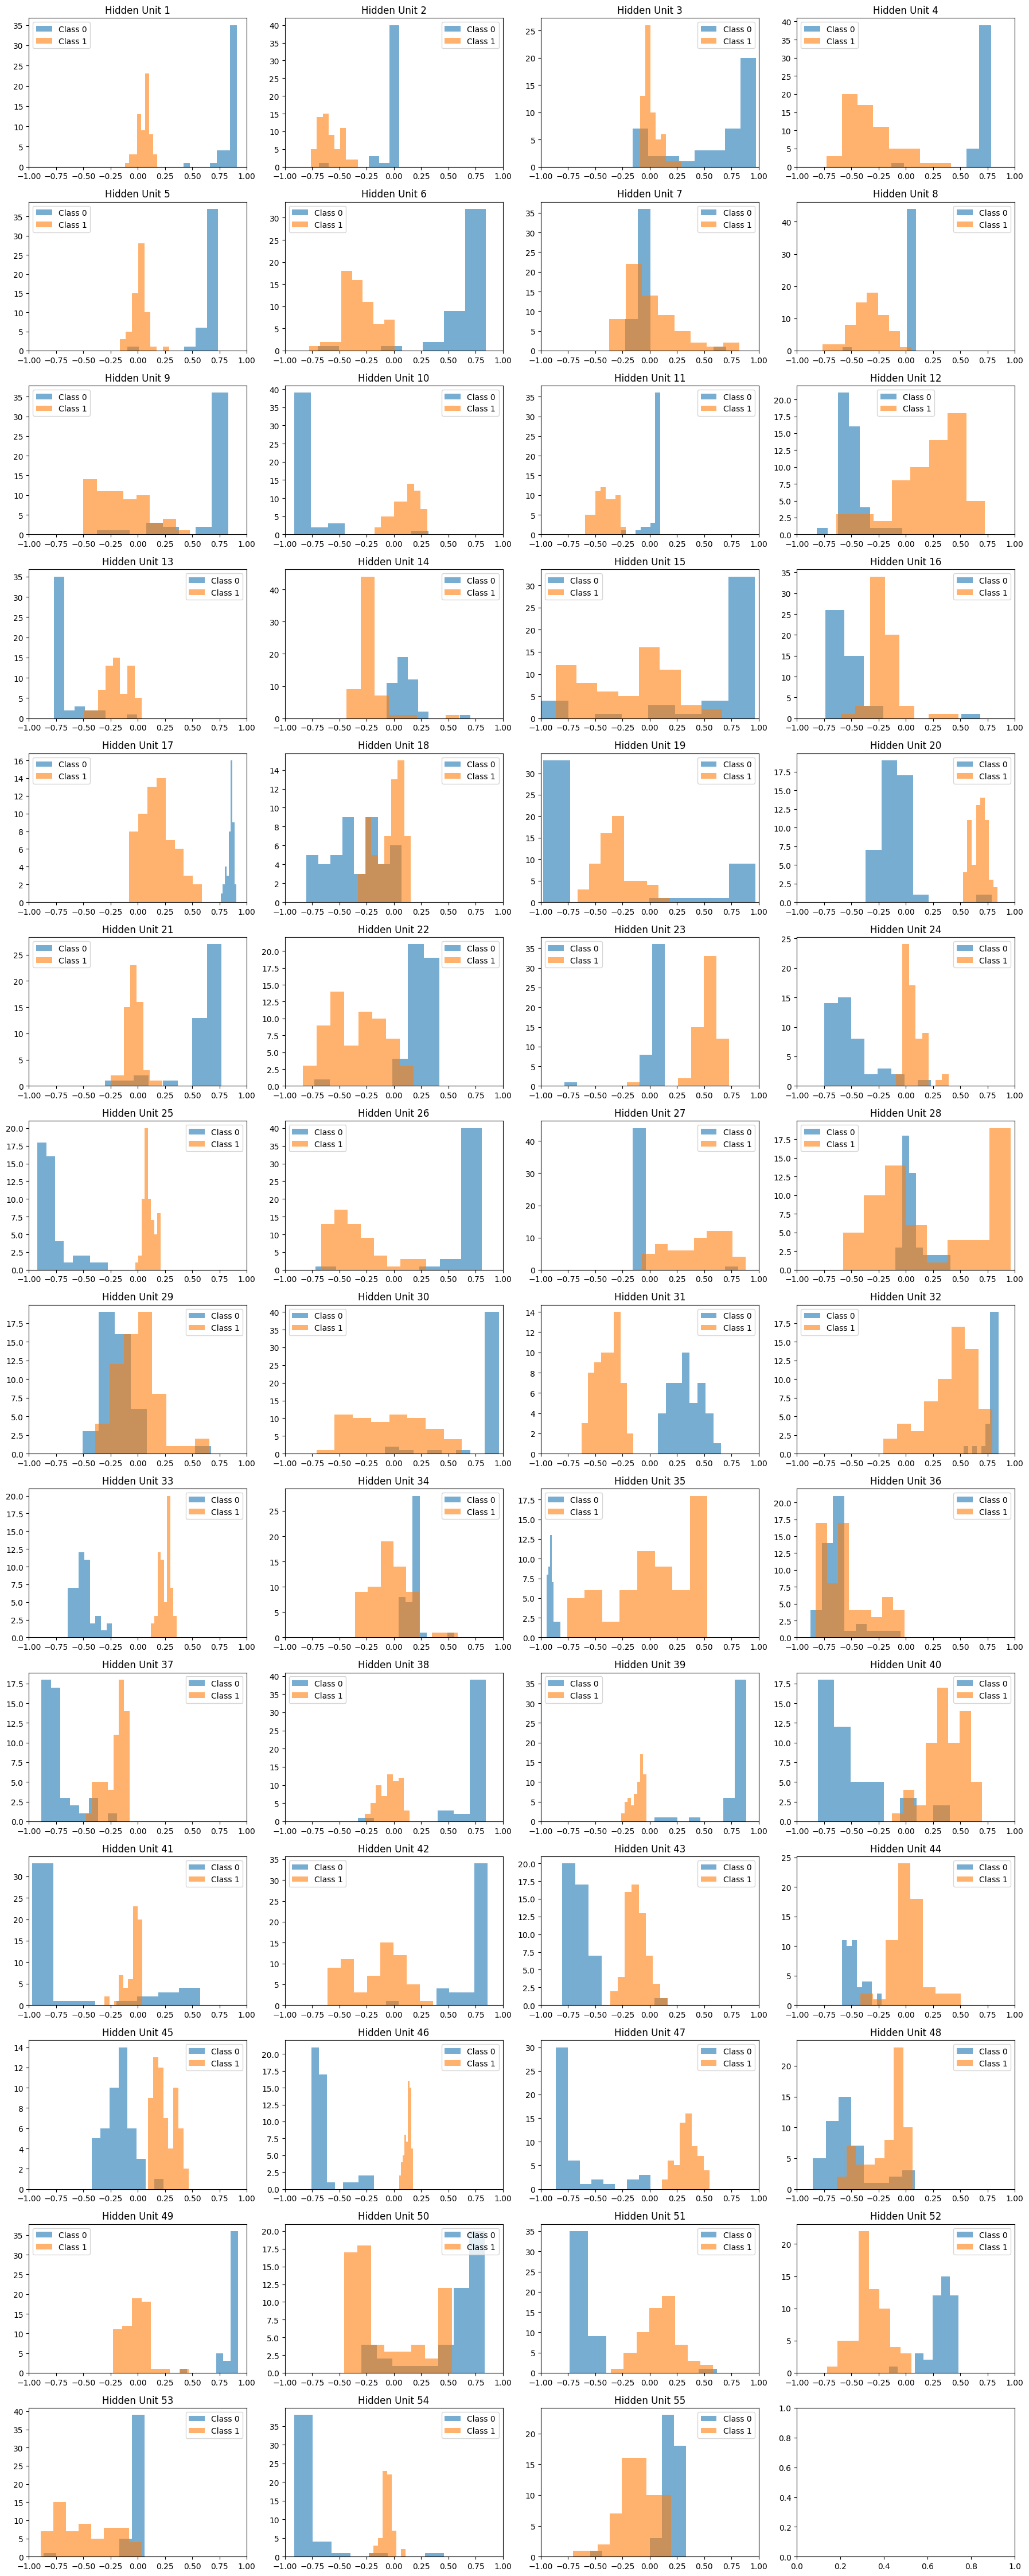

In [22]:
col_plots = 4
row_plots = int(np.ceil(npH.shape[2] / col_plots))

fig, ax = plt.subplots(row_plots, col_plots, figsize=(18, 45), squeeze=False)       # Add squeeze=False if displaying npL

epo = 143  # 8 Select which epoch to visualize
bins = int(np.ceil(np.sqrt(npH.shape[2])))      # Number of bins for histogram

x_max = np.max(npH)
x_min = np.min(npH)

for u in range(npH.shape[2]):
    # Boolean masks over batches
    mask0 = npY[epo, :] == 0
    mask1 = npY[epo, :] == 1

    # # Select hidden unit u for each class
    h0 = npH[epo, mask0, u]
    h1 = npH[epo, mask1, u]
    # print('h0 shape:', h0.shape, 'h1 shape:', h1.shape)
    # print("Class 0 std:", np.std(h0))
    # print("Class 1 std:", np.std(h1))

    r = u // col_plots
    c = u % col_plots
    ax[r, c].hist(h0, bins=bins, alpha=0.6, label="Class 0")
    ax[r, c].hist(h1, bins=bins, alpha=0.6, label="Class 1")
    ax[r, c].set_title(f'Hidden Unit {u+1}')
    ax[r, c].legend()
    ax[r, c].set_xlim(-1, 1)
    #ax[r, c].set_xlim([0, ])

plt.tight_layout()
plt.show()

### PCA

[0.66487825 0.24367195]


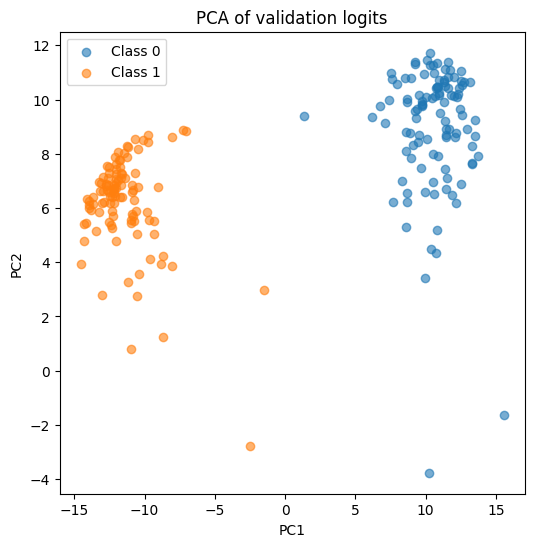

In [47]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

epo = 105
H_pca = pca.fit_transform(npL[epo, :, :])

print(pca.explained_variance_ratio_)

plt.figure(figsize=(6,6))
# npY[epo, :] == 0 - Takes all hidden features where class is 0
# H_pca[npY[epo, :]==0, 0] - Takes all PC1 values where class is 0

# 0 = index con. 
# 1 = index rel. 
# 2 = thumb con. 
# 3 = thumb rel. 
# 4 = rest
sel_class1 = 0
sel_class2 = 1
plt.scatter(H_pca[npY[epo, :] == sel_class1, 0], H_pca[npY[epo, :] == sel_class1, 1], alpha=0.6, label=f"Class {sel_class1}")
plt.scatter(H_pca[npY[epo, :] == sel_class2, 0], H_pca[npY[epo, :] == sel_class2, 1], alpha=0.6, label=f"Class {sel_class2}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA of validation logits")
plt.show()

### T-SNE
Context: “The representation of the trial after the model has decided what time points matter”

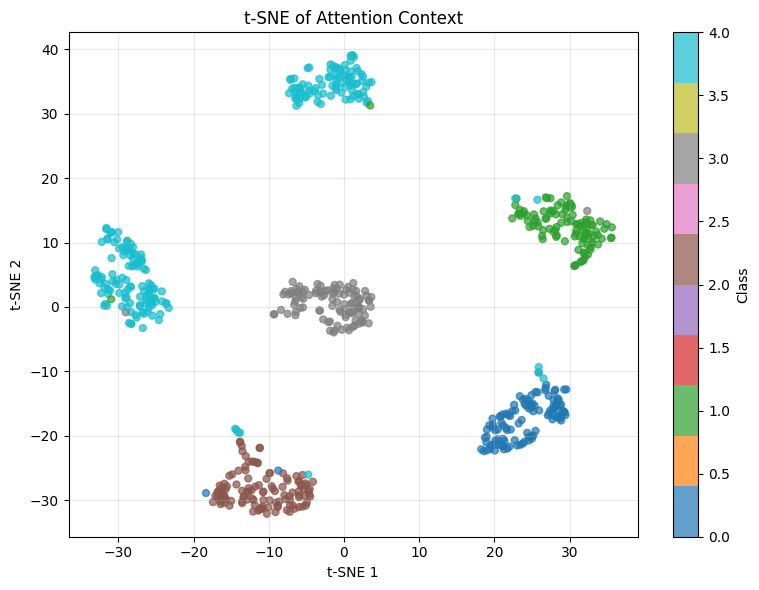

0.63639325


In [50]:
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

def plot_tsne_context(
    context,
    labels,
    perplexity=30,
    n_iter=1000,
    random_state=42,
    title="t-SNE of Attention Context",
    figsize=(8, 6)
):
    """
    Plot t-SNE embedding of attention context vectors.

    Args:
        context (torch.Tensor or np.ndarray):
            Shape (n_samples, feature_dim)
        labels (torch.Tensor or np.ndarray):
            Shape (n_samples,)
        perplexity (int):
            t-SNE perplexity (typ. 5-50)
        n_iter (int):
            Number of optimization iterations
        random_state (int):
            Seed for reproducibility
        title (str):
            Plot title
        figsize (tuple):
            Figure size
    """

    # ---- detach safely ----
    if hasattr(context, "detach"):
        X = context.detach().cpu().numpy()
    else:
        X = np.asarray(context)

    if hasattr(labels, "detach"):
        y = labels.detach().cpu().numpy()
    else:
        y = np.asarray(labels)

    # ---- t-SNE ----
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        n_iter=n_iter,
        init="pca",
        learning_rate="auto",
        random_state=random_state
    )

    X_embedded = tsne.fit_transform(X)

    # ---- plot ----
    plt.figure(figsize=figsize)
    scatter = plt.scatter(
        X_embedded[:, 0],
        X_embedded[:, 1],
        c=y,
        cmap="tab10",
        alpha=0.7,
        s=25
    )

    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.title(title)
    plt.colorbar(scatter, label="Class")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_tsne_context(context = npC[epo, :, :], labels = npY[epo, :], perplexity = 30, n_iter = 1000, random_state = 42)

score = silhouette_score(npC[epo, :, :], npY[epo, :])
print(score)

# ~0.5 → good separation
# ~0.2 → weak separation
# ~0 → no separation
# <0 → overlapping

### Attention weights
This tells you where in time the model is “looking”.

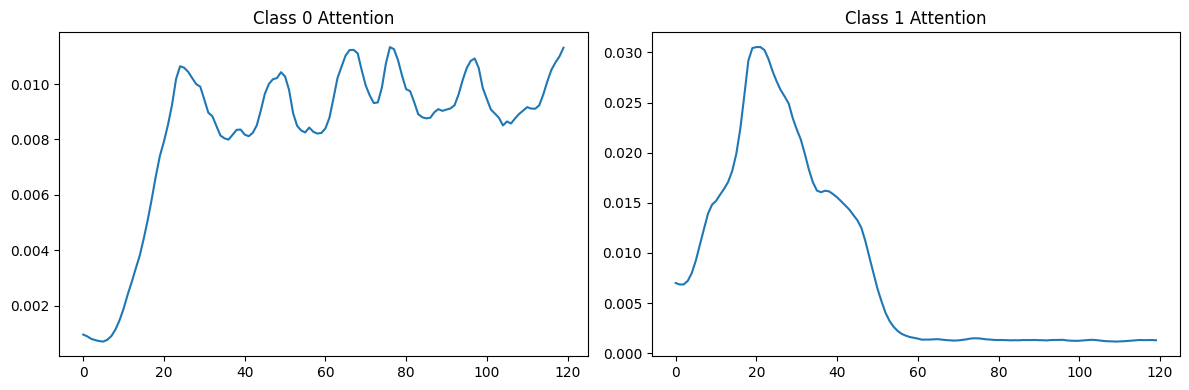

In [25]:
#===========================================#
# Compare Two Epochs from Different Classes #
#===========================================#

# Find one epoch from each class
class0_idx = np.where(npY[:,0] == 1)[0][0]
class1_idx = np.where(npY[:,0] == 3)[0][0]

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(npW[class0_idx, epo].squeeze())
plt.title("Class 0 Attention")

plt.subplot(1,2,2)
plt.plot(npW[class1_idx, epo].squeeze())
plt.title("Class 1 Attention")

plt.tight_layout()
plt.show()


## Model interference

### Re-create the model exactly the same

In [32]:
model_path = Path().resolve() / 'loggings/SingleNet_3sub_EMG_5classes/trial_10/model.pth'

checkpoint = torch.load(f = model_path, map_location = device)

model_interference = SingleNet(**checkpoint["model_args"])
model_interference.load_state_dict(checkpoint["model_state"])
model_interference.to(device)

SingleNet(
  (lstm): LSTM(3, 55, batch_first=True)
  (classifier): Sequential(
    (0): Linear(in_features=55, out_features=27, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.14636760542975918, inplace=False)
    (3): Linear(in_features=27, out_features=5, bias=True)
  )
)

In [38]:
# inference_index_files = load_ins.find_flex_files(
#                 subjects = ['subject_0', 'subject_1'],
#                 modality = 'EMG',
#                 fingers = ['index'],
#                 prefix = 'flex'
# )
# inference_thumb_files = load_ins.find_flex_files(
#                 subjects = ['subject_0', 'subject_1'],
#                 modality = 'EMG',
#                 fingers = ['thumb'],
#                 prefix = 'flex'
# )

# EMG_index_inf, EMG_index_epoch_inf, EMG_index_epoch_mean_inf, total_epochs = load_ins.load_datasets_EMG(
#     path_to_data_files = inference_index_files,
#     preprocessing_func = EMG_ins.preprocessing_routine_rms,
#     sample_window = RMS_SAMPLING_WINDOW,
#     window_stepsize = RMS_WINDOW_STEPSIZE
# )

# EMG_thumb_inf, EMG_thumb_epoch_inf, EMG_thumb_epoch_mean_inf, total_epochs = load_ins.load_datasets_EMG(
#     path_to_data_files = inference_thumb_files,
#     preprocessing_func = EMG_ins.preprocessing_routine_rms,
#     sample_window = RMS_SAMPLING_WINDOW,
#     window_stepsize = RMS_WINDOW_STEPSIZE
# )

#================#
# RELOAD DATASET #
#================#
EMG_index_epoch_inf = EMG_index_epoch.copy()
EMG_thumb_epoch_inf = EMG_thumb_epoch.copy()

In [33]:
X_INF, labels_inf = None, None
#X_INF = np.concatenate((EMG_index_epoch_inf, EMG_thumb_epoch_inf))
#labels_inf = np.concatenate( (np.zeros(EMG_index_epoch_inf.shape[0]), np.ones(EMG_thumb_epoch_inf.shape[0])))
X_INF = X.copy()
labels_inf = labels.copy()

dataset_ins = SingleManageDataset(data = X_INF, labels = labels_inf)
rng = dataset_ins.get_rng_generator()

indices = rng.permutation(len(labels_inf))

inf_dataset = Subset(dataset_ins, indices)

inf_loader = DataLoader(inf_dataset, batch_size=64, shuffle=True, pin_memory=pin_memory, num_workers=0)

data shape: torch.Size([1623, 120, 3])
labels shape: torch.Size([1623])


### Evaluation loop

In [35]:
from sklearn.metrics import confusion_matrix

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in inf_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        logits, h = model_interference(inputs)
        preds = torch.argmax(logits, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)
print(cm)

cm_norm = cm / cm.sum(axis=1, keepdims=True)
print(cm_norm)

accuracy = correct / total
print(f"Test accuracy: {accuracy:.4f}")

[[249   0  20   2   0]
 [  0 261   0   9   1]
 [  3   0 267   0   0]
 [  1   6   0 255   8]
 [  3   4   1   5 528]]
[[0.91881919 0.         0.07380074 0.00738007 0.        ]
 [0.         0.96309963 0.         0.03321033 0.00369004]
 [0.01111111 0.         0.98888889 0.         0.        ]
 [0.0037037  0.02222222 0.         0.94444444 0.02962963]
 [0.00554529 0.00739372 0.00184843 0.00924214 0.97597043]]
Test accuracy: 0.9612


                    Predicted
               | Index  |  Thumb
              -----------------------
True  Index    |   TN   |   FP
True  Thumb    |   FN   |   TP

TN: Predicted index correct
FP: Predicted thumb, but was index
FN: Predicted index, but was thumb
TP: Predicted thumb correct